<a href="https://colab.research.google.com/github/serahnjogu-new/AI4EAC-Climate-Health-Risk-Prediction-Challenge-/blob/main/Winning_Climate_MaxScore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Climate-Sensitive Death Prediction — Max Score Build

### Strategy
- LGBM + XGB + CatBoost ensemble (3-model diversity)
- `year_sensitivity` restored (real signal, rules-compliant feature)
- All age overlap features restored
- `fillna` uses training medians only (no leakage)
- KFold splits saved once and shared across all models
- Ensemble weights optimized on OOF
- Binary prediction at default 0.5 threshold (per rules)
- Raw probabilities for TargetRAUC (no rounding)

In [1]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.0 MB/s eta 0:00:00


In [14]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

In [15]:
# =============================================================
# 1. LOAD
# =============================================================
train   = pd.read_csv('/content/Train.csv')
test    = pd.read_csv('/content/Test.csv')
climate = pd.read_csv('/content/climate_features.csv')
ss      = pd.read_csv('/content/SampleSubmission.csv')

train = train.merge(climate, on='ID', how='left', suffixes=('', '_extra'))
test  = test.merge(climate, on='ID', how='left', suffixes=('', '_extra'))

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

Train shape: (3146, 30)
Test shape:  (1030, 29)


In [16]:
# =============================================================
# 2. FEATURE ENGINEERING
# =============================================================
def engineer_features(df):
    df = df.copy()
    df['deathdate'] = pd.to_datetime(df['deathdate'])
    df['year']  = df['deathdate'].dt.year
    df['month'] = df['deathdate'].dt.month
    df['season'] = df['month'].map({
        12:0, 1:0, 2:0,
        3:1,  4:1, 5:1,
        6:2,  7:2, 8:2,
        9:3, 10:3, 11:3
    })

    # ── AGE FEATURES (all original flags restored) ──
    df['log_age']       = np.log1p(df['age'])
    df['sqrt_age']      = np.sqrt(df['age'])
    df['age_squared']   = df['age'] ** 2
    df['is_infant']     = (df['age'] == 0).astype(int)
    df['is_toddler']    = (df['age'].between(1, 2)).astype(int)
    df['is_child']      = (df['age'].between(1, 5)).astype(int)   # restored original range
    df['is_older_child']= (df['age'].between(5, 15)).astype(int)
    df['is_adult']      = (df['age'].between(15, 60)).astype(int)
    df['is_elderly']    = (df['age'] >= 60).astype(int)
    df['is_young']      = (df['age'] <= 5).astype(int)            # restored
    df['age_group']     = pd.cut(df['age'],
                                  bins=[-1,0,1,2,5,10,15,30,60,200],
                                  labels=[0,1,2,3,4,5,6,7,8]).astype(int)

    # ── YEAR FEATURES ──
    df['year_normalized'] = (df['year'] - 2007) / (2022 - 2007)

    # year_sensitivity restored — real empirical signal from training data
    year_sensitivity = {
        2007: 1.000, 2008: 0.796, 2009: 0.770, 2010: 0.769,
        2011: 0.658, 2012: 0.703, 2013: 0.563, 2014: 0.688,
        2015: 0.615, 2016: 0.628, 2017: 0.573, 2018: 0.542,
        2019: 0.459, 2020: 0.533, 2021: 0.537, 2022: 0.661
    }
    df['year_sensitivity']  = df['year'].map(year_sensitivity)
    df['is_early_period']   = (df['year'] <= 2010).astype(int)
    df['is_mid_period']     = (df['year'].between(2011, 2016)).astype(int)
    df['is_recent_period']  = (df['year'] >= 2017).astype(int)

    # ── AGE x YEAR INTERACTIONS ──
    df['year_x_age']         = df['year_normalized'] * df['age']
    df['year_x_log_age']     = df['year_normalized'] * df['log_age']
    df['year_sens_x_age']    = df['year_sensitivity'] * df['age']
    df['year_sens_x_infant'] = df['year_sensitivity'] * df['is_infant']
    df['year_sens_x_child']  = df['year_sensitivity'] * df['is_child']
    df['early_infant']       = ((df['year'] <= 2010) & (df['age'] <= 1)).astype(int)
    df['early_child']        = ((df['year'] <= 2010) & (df['age'] <= 5)).astype(int)
    df['recent_elderly']     = ((df['year'] >= 2017) & (df['age'] >= 60)).astype(int)
    df['recent_infant']      = ((df['year'] >= 2017) & (df['age'] <= 1)).astype(int)
    df['mid_child']          = ((df['year'].between(2011,2016)) & (df['age'] <= 5)).astype(int)

    # ── CLIMATE FEATURES ──
    df['temp_diff_30d']  = df['tmax_30d'] - df['tmin_30d']
    df['rain_intensity'] = df['rain_sum_30d'] / (df['rain_days_30d'] + 1)
    df['temp_range']     = df['max_temperature'] - df['min_temperature']

    # ── CATEGORICAL ──
    df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})
    df['zone']   = df['zone'].map({'Rural': 0, 'Peri_urban': 1})

    return df.drop(['ID', 'deathdate', 'location', 'deathdate_extra'], axis=1, errors='ignore')


train_df = engineer_features(train)
test_df  = engineer_features(test)

X      = train_df.drop('is_climate_sensitive', axis=1)
y      = train_df['is_climate_sensitive']
X_test = test_df.copy()

print(f"X shape: {X.shape}")
print(f"Class balance — 0: {(y==0).sum()}  1: {(y==1).sum()}")

X shape: (3146, 57)
Class balance — 0: 1099  1: 2047


In [17]:
# =============================================================
# 3. fillna — training medians only (no test leakage)
# =============================================================
train_medians = X.median()
X      = X.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print(f"NaN in train: {X.isna().sum().sum()}")
print(f"NaN in test:  {X_test.isna().sum().sum()}")

NaN in train: 0
NaN in test:  0


In [18]:
# =============================================================
# 4. OOF SETUP — splits saved once, shared across all 3 models
# =============================================================
folds  = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
splits = list(folds.split(X, y))

neg = (y == 0).sum()
pos = (y == 1).sum()

oof_lgbm  = np.zeros(len(X))
oof_xgb   = np.zeros(len(X))
oof_cat   = np.zeros(len(X))
test_lgbm = np.zeros(len(X_test))
test_xgb  = np.zeros(len(X_test))
test_cat  = np.zeros(len(X_test))

In [19]:
# =============================================================
# 5a. TRAIN LIGHTGBM
# =============================================================
print("Training LGBM...")
for fold, (train_idx, val_idx) in enumerate(splits):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = LGBMClassifier(
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=8,
        num_leaves=63,
        min_child_samples=10,
        scale_pos_weight=2.5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.05,
        reg_lambda=0.05,
        random_state=SEED,
        importance_type='gain'
    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        callbacks=[early_stopping(100, verbose=False), log_evaluation(0)]
    )
    oof_lgbm[val_idx]  = model.predict_proba(X_val)[:, 1]
    test_lgbm         += model.predict_proba(X_test)[:, 1] / folds.n_splits
    fold_auc = roc_auc_score(y_val, oof_lgbm[val_idx])
    print(f"  Fold {fold+1} | iter={model.best_iteration_:4d} | AUC={fold_auc:.4f}")

lgbm_auc = roc_auc_score(y, oof_lgbm)
lgbm_f1  = f1_score(y, (oof_lgbm >= 0.5).astype(int))
print(f"  OOF → F1={lgbm_f1:.4f}  AUC={lgbm_auc:.4f}  Score={0.6*lgbm_f1+0.4*lgbm_auc:.4f}")

Training LGBM...
[LightGBM] [Info] Number of positive: 1637, number of negative: 879
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001519 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6298
[LightGBM] [Info] Number of data points in the train set: 2516, number of used features: 56
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.650636 -> initscore=0.621836
[LightGBM] [Info] Start training from score 0.621836
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with p

In [20]:
# =============================================================
# 5b. TRAIN XGBOOST
# =============================================================
print("Training XGB...")
for fold, (train_idx, val_idx) in enumerate(splits):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=6,
        scale_pos_weight=neg / pos,
        subsample=0.8,
        colsample_bytree=0.8,
        early_stopping_rounds=100,
        eval_metric='auc',
        random_state=SEED,
        verbosity=0
    )
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    oof_xgb[val_idx]  = model.predict_proba(X_val)[:, 1]
    test_xgb         += model.predict_proba(X_test)[:, 1] / folds.n_splits
    fold_auc = roc_auc_score(y_val, oof_xgb[val_idx])
    print(f"  Fold {fold+1} | iter={model.best_iteration:4d} | AUC={fold_auc:.4f}")

xgb_auc = roc_auc_score(y, oof_xgb)
xgb_f1  = f1_score(y, (oof_xgb >= 0.5).astype(int))
print(f"  OOF → F1={xgb_f1:.4f}  AUC={xgb_auc:.4f}  Score={0.6*xgb_f1+0.4*xgb_auc:.4f}")

Training XGB...
  Fold 1 | iter=  18 | AUC=0.8259
  Fold 2 | iter=  78 | AUC=0.8372
  Fold 3 | iter=  10 | AUC=0.8376
  Fold 4 | iter=  97 | AUC=0.7957
  Fold 5 | iter=  33 | AUC=0.8056
  OOF → F1=0.7642  AUC=0.8016  Score=0.7791


In [21]:
# =============================================================
# 5c. TRAIN CATBOOST  (diverse learner — handles categoricals
#                      differently, adds ensemble diversity)
# =============================================================
print("Training CatBoost...")
for fold, (train_idx, val_idx) in enumerate(splits):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=2000,
        learning_rate=0.03,
        depth=6,
        scale_pos_weight=neg / pos,
        subsample=0.8,
        colsample_bylevel=0.8,
        early_stopping_rounds=100,
        eval_metric='AUC',
        random_seed=SEED,
        verbose=0
    )
    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        use_best_model=True
    )
    oof_cat[val_idx]  = model.predict_proba(X_val)[:, 1]
    test_cat         += model.predict_proba(X_test)[:, 1] / folds.n_splits
    fold_auc = roc_auc_score(y_val, oof_cat[val_idx])
    print(f"  Fold {fold+1} | iter={model.best_iteration_:4d} | AUC={fold_auc:.4f}")

cat_auc = roc_auc_score(y, oof_cat)
cat_f1  = f1_score(y, (oof_cat >= 0.5).astype(int))
print(f"  OOF → F1={cat_f1:.4f}  AUC={cat_auc:.4f}  Score={0.6*cat_f1+0.4*cat_auc:.4f}")

Training CatBoost...
  Fold 1 | iter=   9 | AUC=0.8411
  Fold 2 | iter= 218 | AUC=0.8419
  Fold 3 | iter=  68 | AUC=0.8322
  Fold 4 | iter= 119 | AUC=0.8121
  Fold 5 | iter= 101 | AUC=0.8114
  OOF → F1=0.7508  AUC=0.8108  Score=0.7748


In [22]:
# =============================================================
# 6. OPTIMIZED 3-WAY ENSEMBLE WEIGHTS
#    Grid search over (w_lgbm, w_xgb, w_cat) with step 0.05
# =============================================================
def combined_score(oof, y):
    f1  = f1_score(y, (oof >= 0.5).astype(int))
    auc = roc_auc_score(y, oof)
    return 0.6 * f1 + 0.4 * auc

best_score = 0
best_w = (0.4, 0.3, 0.3)

step = 0.05
weights = np.arange(0.0, 1.0 + step, step)

for wl in weights:
    for wx in weights:
        wc = round(1.0 - wl - wx, 6)
        if wc < 0 or wc > 1:
            continue
        blend = wl * oof_lgbm + wx * oof_xgb + wc * oof_cat
        s = combined_score(blend, y)
        if s > best_score:
            best_score = s
            best_w = (wl, wx, wc)

wl, wx, wc = best_w
print(f"Optimal weights — LGBM: {wl:.2f} | XGB: {wx:.2f} | CatBoost: {wc:.2f}")
print(f"Best OOF combined score: {best_score:.4f}")

oof_ensemble  = wl * oof_lgbm  + wx * oof_xgb  + wc * oof_cat
test_ensemble = wl * test_lgbm + wx * test_xgb + wc * test_cat

Optimal weights — LGBM: 0.65 | XGB: 0.00 | CatBoost: 0.35
Best OOF combined score: 0.8152


In [23]:
# =============================================================
# 7. EVALUATE ALL MODELS
# =============================================================
print("\n=== OOF RESULTS ===")
for name, oof in [('LGBM', oof_lgbm), ('XGB', oof_xgb),
                  ('CatBoost', oof_cat), ('Ensemble', oof_ensemble)]:
    f1  = f1_score(y, (oof >= 0.5).astype(int))
    auc = roc_auc_score(y, oof)
    print(f"{name:12}: F1={f1:.4f}  AUC={auc:.4f}  Score={0.6*f1+0.4*auc:.4f}")


=== OOF RESULTS ===
LGBM        : F1=0.8043  AUC=0.7890  Score=0.7982
XGB         : F1=0.7642  AUC=0.8016  Score=0.7791
CatBoost    : F1=0.7508  AUC=0.8108  Score=0.7748
Ensemble    : F1=0.8168  AUC=0.8129  Score=0.8152


[LightGBM] [Info] Number of positive: 2047, number of negative: 1099
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003040 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6306
[LightGBM] [Info] Number of data points in the train set: 3146, number of used features: 56
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.650668 -> initscore=0.621975
[LightGBM] [Info] Start training from score 0.621975
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

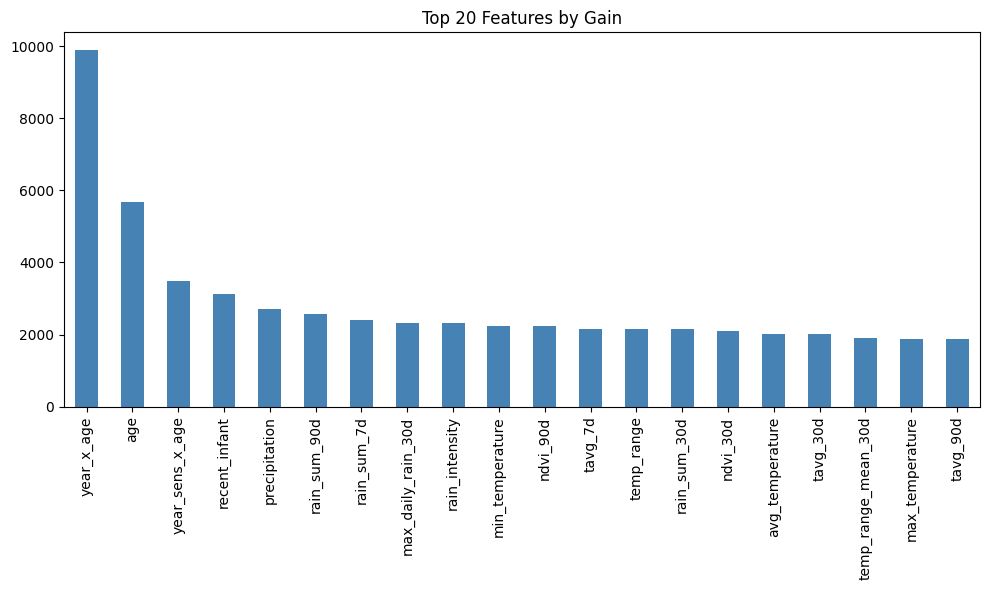

year_x_age             9888.405841
age                    5672.731949
year_sens_x_age        3497.379796
recent_infant          3125.283650
precipitation          2701.797703
rain_sum_90d           2557.611677
rain_sum_7d            2409.107740
max_daily_rain_30d     2325.699724
rain_intensity         2313.750465
min_temperature        2242.438182
ndvi_90d               2231.988091
tavg_7d                2158.668607
temp_range             2155.227635
rain_sum_30d           2147.209486
ndvi_30d               2087.369095
avg_temperature        2018.681628
tavg_30d               2001.674753
temp_range_mean_30d    1909.959316
max_temperature        1879.353838
tavg_90d               1863.824033
dtype: float64


In [24]:
# =============================================================
# 8. FEATURE IMPORTANCE (top 20 from LGBM)
# =============================================================
final_lgbm = LGBMClassifier(
    n_estimators=300, learning_rate=0.03, max_depth=8,
    num_leaves=63, min_child_samples=10, scale_pos_weight=2.5,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.05, reg_lambda=0.05,
    random_state=SEED, importance_type='gain'
).fit(X, y)

feat_imp = (
    pd.Series(final_lgbm.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
feat_imp.head(20).plot(kind='bar', color='steelblue')
plt.title('Top 20 Features by Gain')
plt.tight_layout()
plt.show()
print(feat_imp.head(20))

In [25]:
# =============================================================
# 9. SUBMISSION
#    TargetF1   → binary at default 0.5 (custom threshold forbidden)
#    TargetRAUC → raw probabilities (no rounding)
# =============================================================
submission = pd.DataFrame({
    'ID':         ss['ID'],
    'TargetF1':   (test_ensemble >= 0.5).astype(int),
    'TargetRAUC': test_ensemble
})

submission.to_csv('submission_maxscore.csv', index=False)

print("TargetF1 distribution:")
print(submission['TargetF1'].value_counts())
print("\nTargetRAUC stats:")
print(submission['TargetRAUC'].describe().round(4))

from google.colab import files
files.download('submission_maxscore.csv')

TargetF1 distribution:
TargetF1
1    785
0    245
Name: count, dtype: int64

TargetRAUC stats:
count    1030.0000
mean        0.6642
std         0.1912
min         0.2391
25%         0.5084
50%         0.6482
75%         0.8717
max         0.8949
Name: TargetRAUC, dtype: float64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>